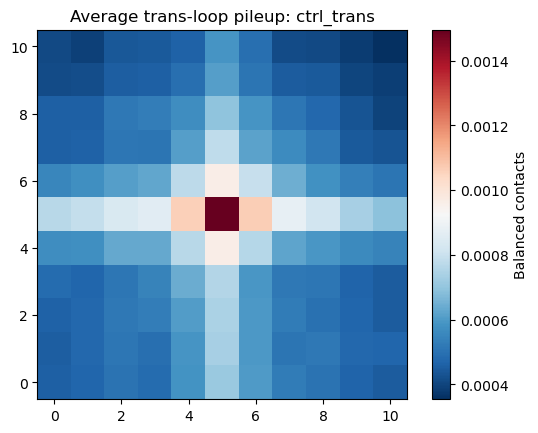

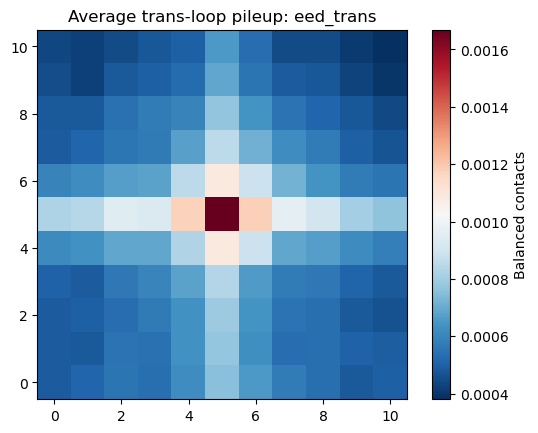

In [5]:
#!/usr/bin/env python3
import cooler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def make_pileup(cool_path, bedpe_file, output_prefix, flank=500_000, resolution=100_000):
    # Load cooler
    clr = cooler.Cooler(cool_path)

    # Read BEDPE
    loops = pd.read_csv(
        bedpe_file, sep="\t", header=None,
        names=["chr1","start1","end1","chr2","start2","end2"]
    )

    halfwin_bins = flank // resolution
    pileups = []

    for _, row in loops.iterrows():
        try:
            mat = clr.matrix(balance=True).fetch(
                (row.chr1, row.start1 - flank, row.end1 + flank),
                (row.chr2, row.start2 - flank, row.end2 + flank)
            )
            # Only keep if matrix size is correct
            if mat.shape == (2*halfwin_bins + 1, 2*halfwin_bins + 1):
                pileups.append(mat)
        except Exception:
            continue

    if not pileups:
        print(f"No valid pileups found in {bedpe_file}")
        return

    avg = np.nanmean(pileups, axis=0)

    # Plot
    plt.imshow(avg, cmap="RdBu_r", origin="lower")
    plt.colorbar(label="Balanced contacts")
    plt.title(f"Average trans-loop pileup: {output_prefix}")
    plt.savefig(f"{output_prefix}_pileup.png", dpi=300)
    plt.savefig(f"{output_prefix}_pileup.pdf")
    plt.show()
    plt.close()

# ---- Run for CTRL ----
ctrl_cool = "/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/100000"
ctrl_bedpe = "/usr/users/papantonis1/fithic-master/fithic/utils/fithic_outputs/ctrl.trans.q01.final.bedpe"
make_pileup(ctrl_cool, ctrl_bedpe, "ctrl_trans")

# ---- Run for RBP1 ----
rbp1_cool = "/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/100000"
rbp1_bedpe = "/usr/users/papantonis1/fithic-master/fithic/utils/fithic_outputs/rbp1.trans.q01.final.bedpe"
make_pileup(rbp1_cool, rbp1_bedpe, "eed_trans")